In [7]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [13]:
# load the sales dataset 
sales = pd.read_csv(r"Downloads\sales_from_claude.csv")
pd.reset_option('display.max_rows')
sales

,order_id,order_date,customer_id,customer_segment,region,state,category,sub_category,product_name,quantity,unit_price,discount_pct,sales_amount,profit,payment_method,shipping_mode,customer_rating,returned
0,ORD-133553,02-03-2021,CUST-1636,Consumer,Central,Karnataka,Grocery,Snacks,Snacks Basic,4,55.76,20,178.43,17.45,Credit Card,Economy,2.0,Yes
1,ORD-109427,30-10-2022,CUST-3981,SMB,North,Karnataka,Books,Fiction,Fiction Lite,2,43.17,10,77.71,13.87,Net Banking,Economy,4.0,No
2,ORD-100199,31-08-2022,CUST-6599,SMB,Central,Rajasthan,Clothing,Jeans,Jeans Plus,2,22.84,0,45.68,9.25,Wallet,Same Day,2.0,No
3,ORD-112447,15-07-2021,CUST-3282,Home Office,East,rajasthan,Electronics,Headphones,Headphones Plus,3,21.50,5,61.28,15.39,Wallet,Standard,5.0,No
4,ORD-139489,28-02-2022,CUST-2079,Corporate,West,NaN,Clothing,Shoes,Shoes Pro,4,391.59,0,1566.36,280.69,EMI,Express,4.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,ORD-121144,08-02-2022,CUST-8649,Corporate,Central,Gujarat,Toys,LEGO,LEGO,2,41.52,25,62.28,17.71,Credit Card,Same Day,3.0,No
49996,ORD-144732,04-07-2022,CUST-4163,Consumer,Central,WB,Toys,Dolls,Dolls Pro,3,39.77,25,89.48,25.94,Debit Card,Economy,4.0,NaN
49997,ORD-138158,31-12-2021,CUST-2393,SMB,West,MP,Furniture,Chair,Chair Plus,5,51.90,10,233.55,48.05,Credit Card,Economy,5.0,No
49998,ORD-100860,25-08-2021,CUST-2559,Corporate,North,Rajasthan,Grocery,Snacks,Snacks,2,114.84,10,206.71,31.13,Credit Card,Standard,4.0,No


In [14]:
# understanding the daset 
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  object 
 1   order_date        50000 non-null  object 
 2   customer_id       50000 non-null  object 
 3   customer_segment  48500 non-null  object 
 4   region            50000 non-null  object 
 5   state             49000 non-null  object 
 6   category          50000 non-null  object 
 7   sub_category      50000 non-null  object 
 8   product_name      50000 non-null  object 
 9   quantity          50000 non-null  int64  
 10  unit_price        50000 non-null  float64
 11  discount_pct      50000 non-null  int64  
 12  sales_amount      50000 non-null  float64
 13  profit            50000 non-null  float64
 14  payment_method    48500 non-null  object 
 15  shipping_mode     48500 non-null  object 
 16  customer_rating   48003 non-null  float6

In [15]:
sales.describe()

,quantity,unit_price,discount_pct,sales_amount,profit,customer_rating
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,48003.000000
mean,3.538100,184.288868,9.687600,660.603340,138.748142,3.751870
std,3.092614,327.665376,8.728226,3023.303076,440.119265,1.142684
min,1.000000,0.420000,0.000000,1.010000,-7050.400000,0.000000
25%,1.000000,39.870000,0.000000,79.127500,14.290000,3.000000
50%,3.000000,90.205000,10.000000,206.535000,42.630000,4.000000
75%,5.000000,202.847500,15.000000,559.025000,125.185000,5.000000
max,19.000000,19436.370000,30.000000,288501.380000,35540.610000,6.000000


In [ ]:
# cleaning the datset

# drop last unwanted column
sales.drop(columns=['Unnamed: 18','Unnamed: 19'] , inplace = True)

In [16]:
# convert the order_date into the date datype
sales['order_date']= pd.to_datetime(sales['order_date'],  format='%d-%m-%Y')

In [17]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          50000 non-null  object        
 1   order_date        50000 non-null  datetime64[ns]
 2   customer_id       50000 non-null  object        
 3   customer_segment  48500 non-null  object        
 4   region            50000 non-null  object        
 5   state             49000 non-null  object        
 6   category          50000 non-null  object        
 7   sub_category      50000 non-null  object        
 8   product_name      50000 non-null  object        
 9   quantity          50000 non-null  int64         
 10  unit_price        50000 non-null  float64       
 11  discount_pct      50000 non-null  int64         
 12  sales_amount      50000 non-null  float64       
 13  profit            50000 non-null  float64       
 14  payment_method    4850

In [18]:
sales.isnull().sum()

order_id               0
order_date             0
customer_id            0
customer_segment    1500
region                 0
state               1000
category               0
sub_category           0
product_name           0
quantity               0
unit_price             0
discount_pct           0
sales_amount           0
profit                 0
payment_method      1500
shipping_mode       1500
customer_rating     1997
returned            3096
dtype: int64

In [19]:
# replace the null values 
sales['customer_segment'] = sales['customer_segment'].fillna(sales['customer_segment'].mode()[0])

sales["state"] = sales["state"].fillna("unknown")

sales['payment_method'] = sales['payment_method'].fillna(sales['payment_method'].mode()[0])

sales['shipping_mode'] = sales['shipping_mode'].fillna(sales['shipping_mode'].mode()[0])

sales['customer_rating'] = sales['customer_rating'].fillna(sales['customer_rating'].median())

sales["returned"] = sales["returned"].fillna("N/A")

In [20]:
# after treatment of null values 
sales.isnull().sum()

order_id            0
order_date          0
customer_id         0
customer_segment    0
region              0
state               0
category            0
sub_category        0
product_name        0
quantity            0
unit_price          0
discount_pct        0
sales_amount        0
profit              0
payment_method      0
shipping_mode       0
customer_rating     0
returned            0
dtype: int64

In [21]:
# Convert every string in the entire table to lowercase
sales = sales.map(lambda x: x.lower() if isinstance(x, str) else x)

exploratory data analysis

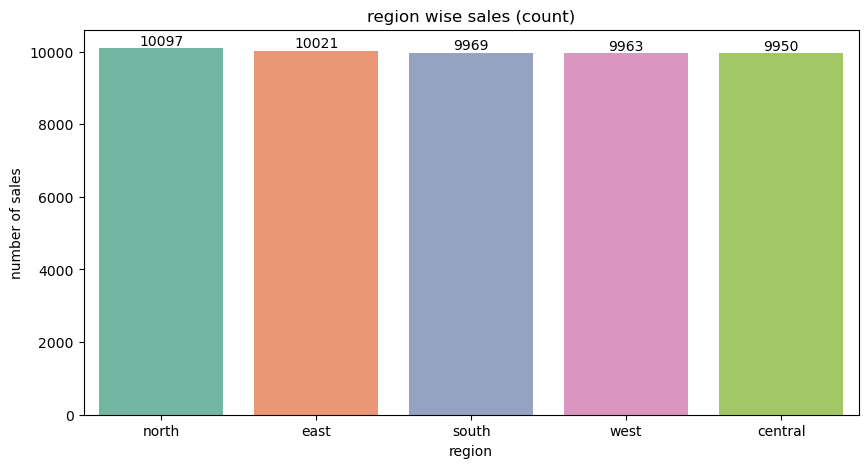

In [148]:
# region wise sales sales (count)

plt.figure(figsize= (10,5))

region_sales_count= sales.groupby('region')['sales_amount'].count().reset_index().sort_values( by = 'sales_amount', ascending = False)

ax=sns.barplot(x ='region', y ='sales_amount',
               data = region_sales_count, palette = 'Set2', hue='region')

for bars in ax.containers:
   ax.bar_label(bars)

plt.title('region wise sales (count)')
plt.xlabel('region')
plt.ylabel('number of sales')

plt.show()


In [ ]:
# insight : north region has the highest sales count and central region has the lowest sales count

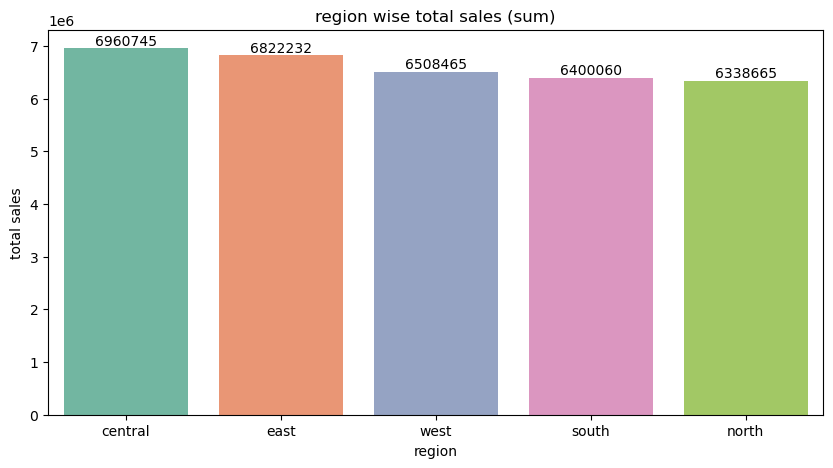

In [151]:
# region wise sales (sum)

plt.figure(figsize = (10,5))

region_sales_sum = sales.groupby('region')['sales_amount'].sum().reset_index().sort_values(by= 'sales_amount', ascending = False)

ax =sns.barplot(x= 'region', y ='sales_amount', 
            data = region_sales_sum, palette = 'Set2', hue = 'region' )

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.0f')

plt.title('region wise total sales (sum)') 
plt.xlabel('region')
plt.ylabel('total sales')

plt.show()

In [ ]:
insight: central region has the highest sales amount and north has lowest sales amount

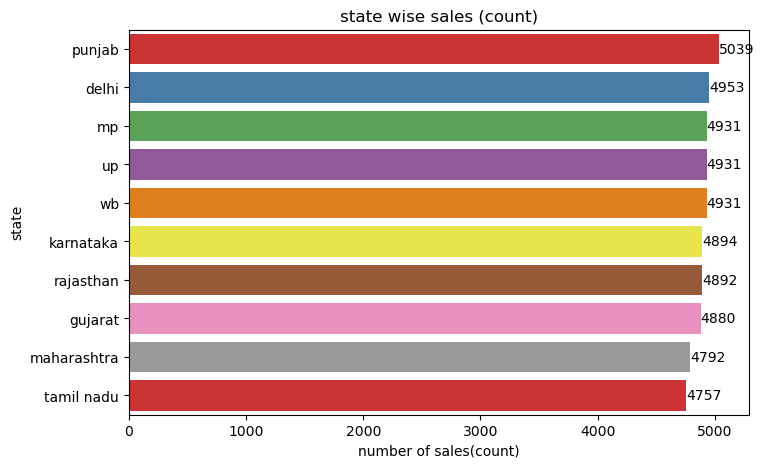

In [152]:
# state wise sales (count)
plt.figure(figsize = (8, 5))

filtered_sales = sales[sales['state'] != 'unknown' ]

region_sales_count= filtered_sales.groupby('state')['sales_amount'].count().reset_index().sort_values(by = 'sales_amount', ascending= False)

ax = sns.barplot(x = 'sales_amount', y = 'state', data = region_sales_count,  palette = 'Set1', hue = 'state')

for bars in ax.containers:
    ax.bar_label(bars)

plt.title('state wise sales (count)')
plt.xlabel('number of sales(count)')
plt.ylabel('state')

plt.show()

In [ ]:
# insight: punjab has the highest sales count(5000+), but reversly the tamil_nadu has lowest sales count

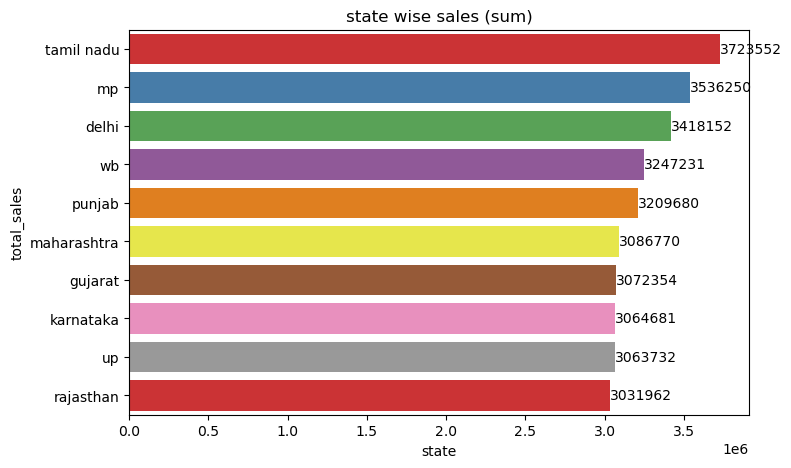

In [153]:
# state wise sales (sum)
plt.figure(figsize = (8,5))

filtered_sales = sales[sales['state'] != 'unknown']

state_sales_sum = filtered_sales.groupby('state')['sales_amount'].sum().reset_index().sort_values(by = 'sales_amount', ascending = False)

ax = sns.barplot(x= 'sales_amount', y = 'state', data =state_sales_sum, hue= 'state', palette = 'Set1')

for bars in ax.containers:
    ax.bar_label(bars, fmt = '%.0f')

plt.title('state wise sales (sum)') 
plt.xlabel('state')
plt.ylabel('total_sales')

plt.show()

In [ ]:
# insight: tamil_nadu has the highest purchasing amount state(37+ lakh sales)

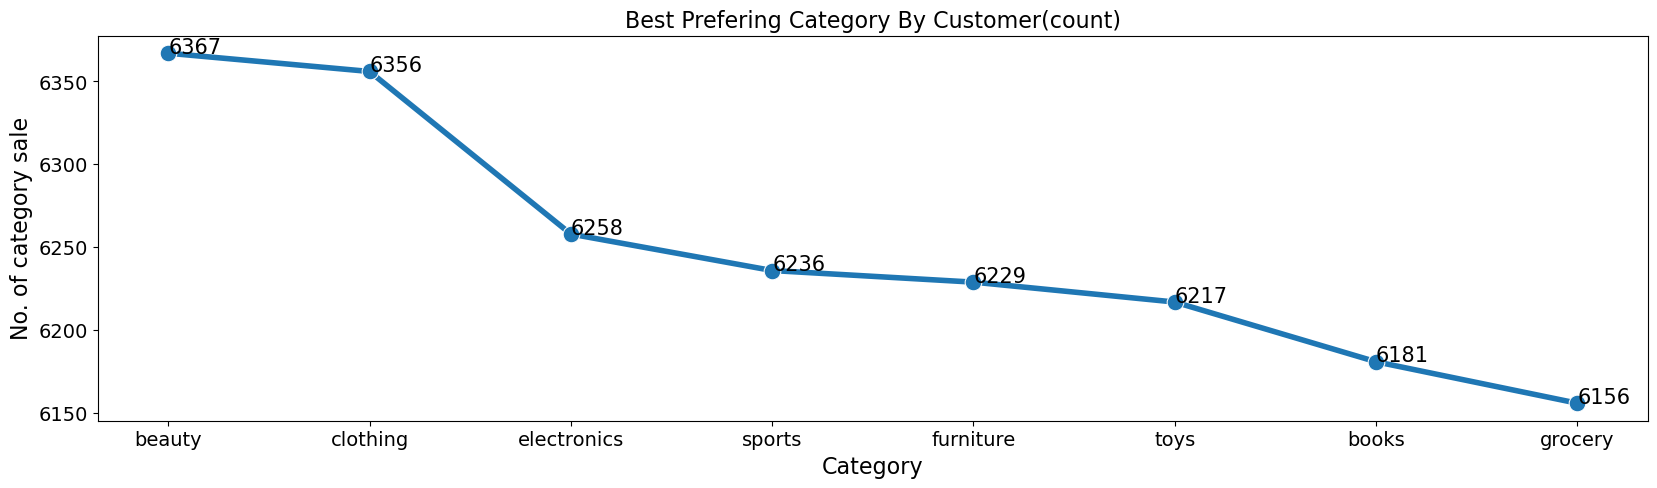

In [63]:
# category count

category_count = sales['category'].value_counts().reset_index()

category_count.columns = ['category', 'count']

plt.figure(figsize=(20,5))

ax = sns.lineplot(
    data=category_count,
    x='category',
    y='count',
    marker='o',
    markersize= 12,
    linewidth = 4
)

for x, y in zip(category_count['category'], category_count['count']):
    plt.text(x, y, str(y), fontsize=15)

plt.title('Best Prefering Category By Customer(count)', fontsize=16)
plt.xlabel('Category', fontsize=16)
plt.ylabel('No. of category sale', fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

In [ ]:
# customer prefer the beauty & clothing most, not huge difference of category of puchasing 

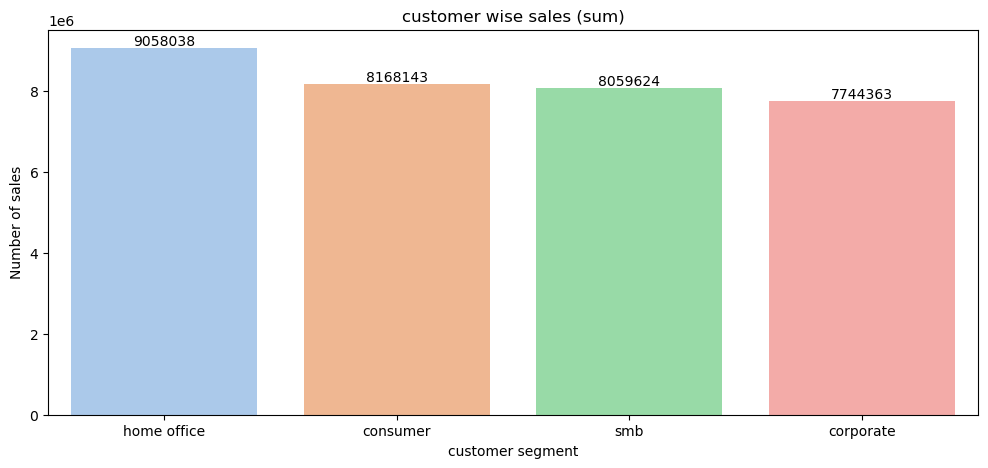

In [86]:
# customer segment wise sales_amount (sum)

plt.figure(figsize =(12,5))

cust_seg_sales_count = sales.groupby('customer_segment')['sales_amount'].sum().reset_index().sort_values(by= 'sales_amount', ascending = False)

ax = sns.barplot(x = 'customer_segment', y = 'sales_amount', data = cust_seg_sales_count, hue = 'customer_segment', palette = 'pastel' )

for bars in ax.containers:
    ax.bar_label(bars, fmt = '%.0f')

plt.title('customer wise sales (sum)') 
plt.xlabel('customer segment')
plt.ylabel('Number of sales')

plt.show()


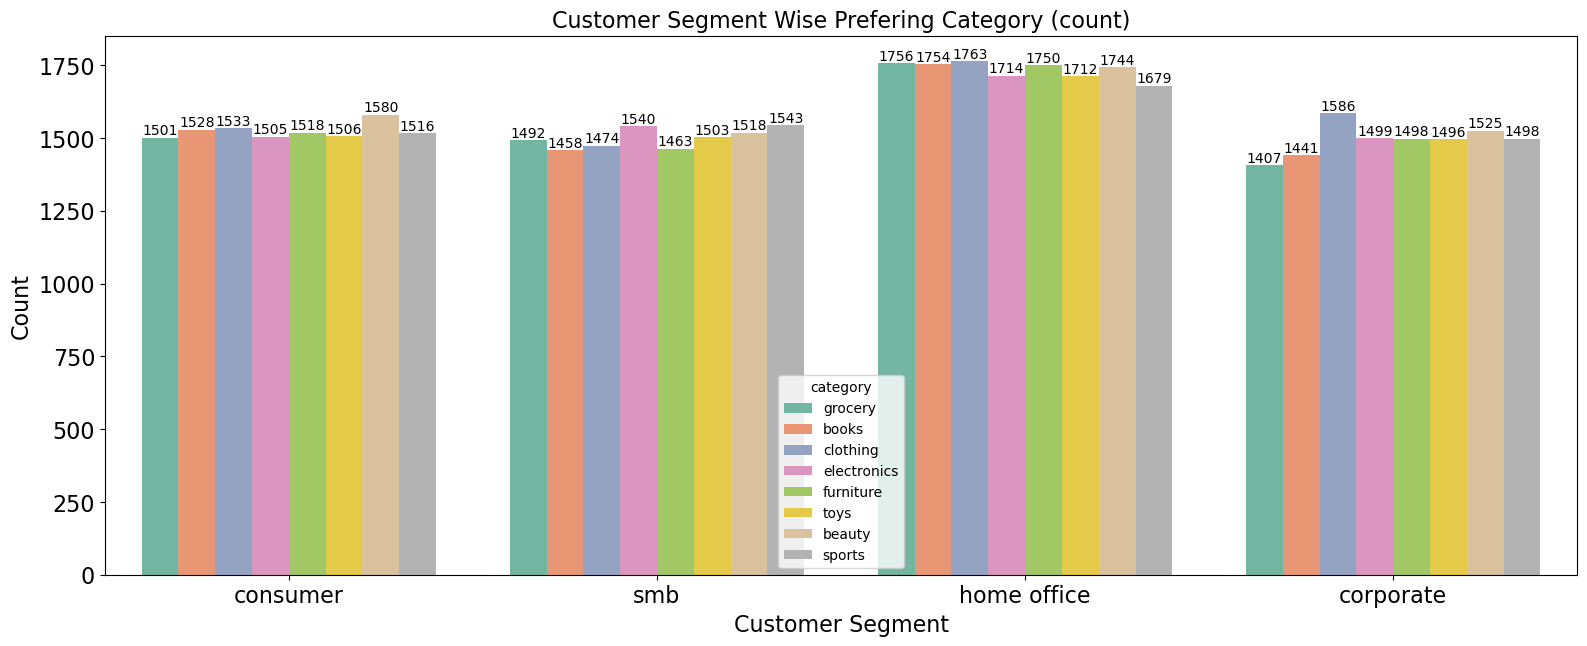

In [154]:
# customer_segment wise category preference

plt.figure(figsize=(19,7))

ax = sns.countplot(
    data=sales,
    x='customer_segment',
    hue='category',
    palette='Set2'
)

# Data labels
for bars in ax.containers:
    ax.bar_label(bars, fontsize = 10)

# Titles
plt.title('Customer Segment Wise Prefering Category (count)', fontsize=16)
plt.xlabel('Customer Segment', fontsize=16)
plt.ylabel('Count', fontsize=16)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.show()

In [ ]:
# insight: home_office customer segment has the highest purchasing count as well as highest purchasing amount , prefer the clothing category most 

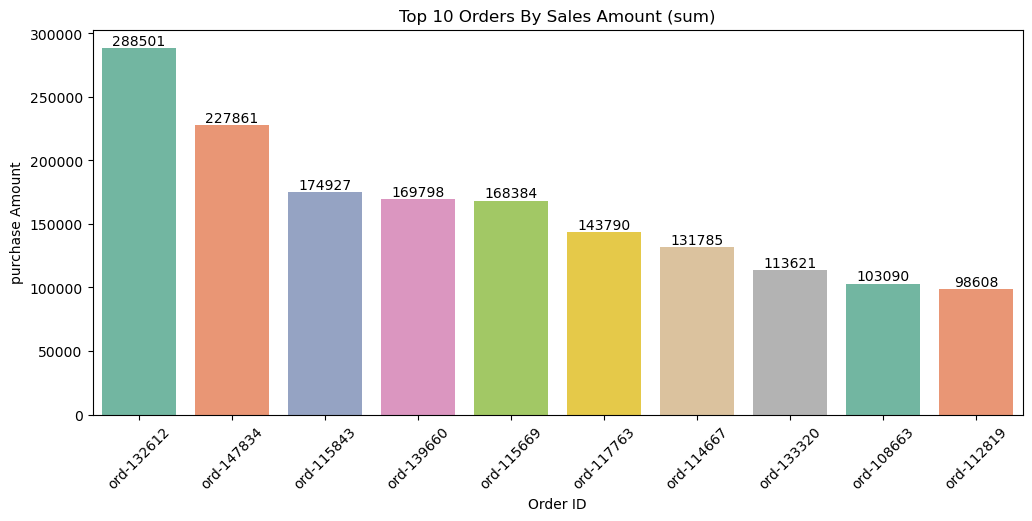

In [155]:
# Top 10 orders
order_sales = sales.groupby('order_id')['sales_amount'] \
    .sum() \
    .reset_index() \
    .sort_values(by='sales_amount', ascending=False) \
    .head(10)

# Figure size
plt.figure(figsize=(12,5))

# Barplot
ax = sns.barplot(
    x='order_id',
    y='sales_amount',
    data=order_sales,
    palette='Set2',
    hue='order_id',
    legend=False
)

# Labels
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.0f')

# Titles
plt.title('Top 10 Orders By Sales Amount (sum)')
plt.xlabel('Order ID')
plt.ylabel('purchase Amount')

plt.xticks(rotation=45)

plt.show()


In [ ]:
# insight: order_id has "ORD-132612" is most valued customer

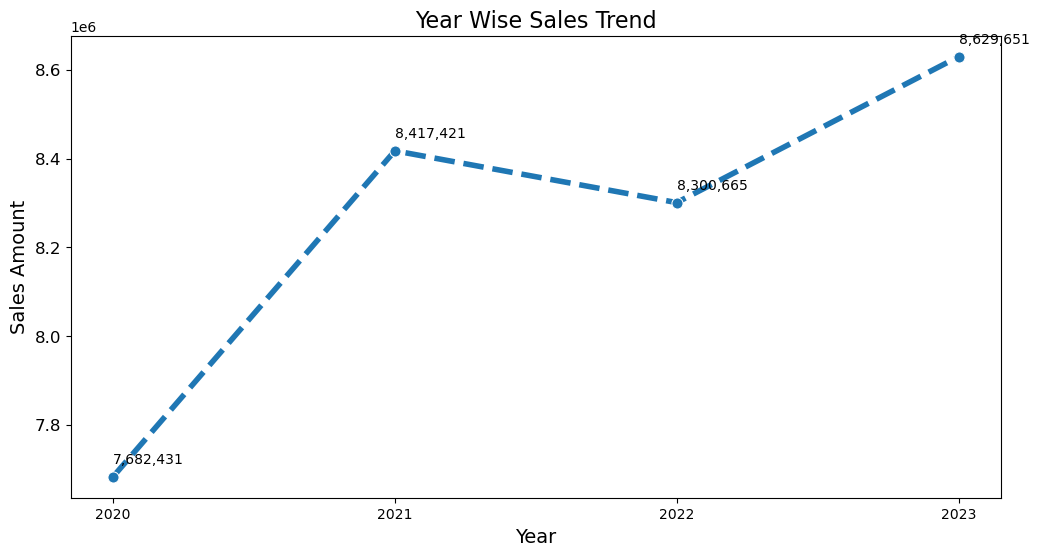

In [132]:
# year wise sales trend 

plt.figure(figsize=(12,6))

year_sales = sales.groupby(
    sales['order_date'].dt.year
)['sales_amount'].sum().reset_index()

ax = sns.lineplot(
    data=year_sales,
    x='order_date',
    y='sales_amount',
    marker='o',
    linewidth=4,
    markersize=8,
    linestyle='--'
)

# Data labels
for x, y in zip(year_sales['order_date'], year_sales['sales_amount']):
    plt.text(x, y+30000, f'{y:,.0f}', fontsize=10)

# Titles
plt.title('Year Wise Sales Trend', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Sales Amount', fontsize=14)

plt.xticks(
    ticks=year_sales['order_date'],
    labels=year_sales['order_date'].astype(int)
)
plt.yticks(fontsize=12)

plt.show()

In [ ]:
# insight: years wise sales trend growing instead of previos years 

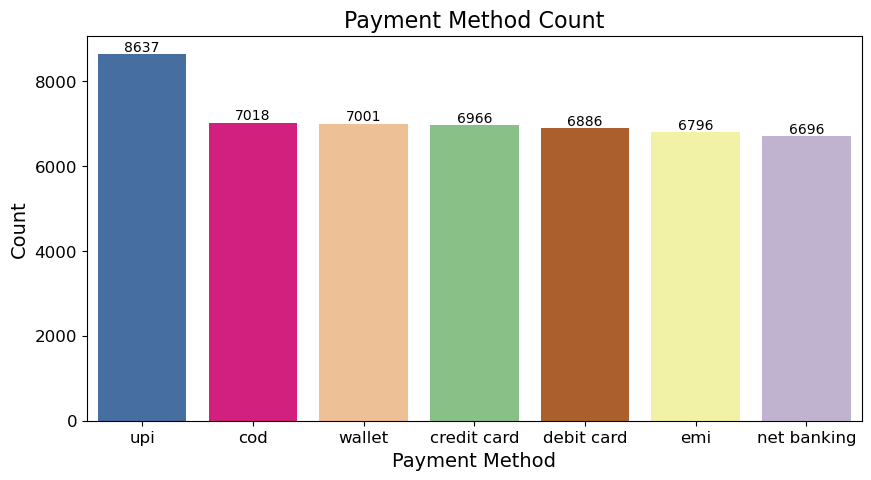

In [156]:
# payment method (count) 

plt.figure(figsize=(10,5))

ax = sns.countplot(data=sales, x='payment_method', order=sales['payment_method'].value_counts().index, palette='Accent', hue='payment_method',legend=False)

# Data labels
for bars in ax.containers:
    ax.bar_label(bars)

# Titles
plt.title('Payment Method Count', fontsize=16)
plt.xlabel('Payment Method', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Axis text size
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()


In [ ]:
# most used payment method is UPI

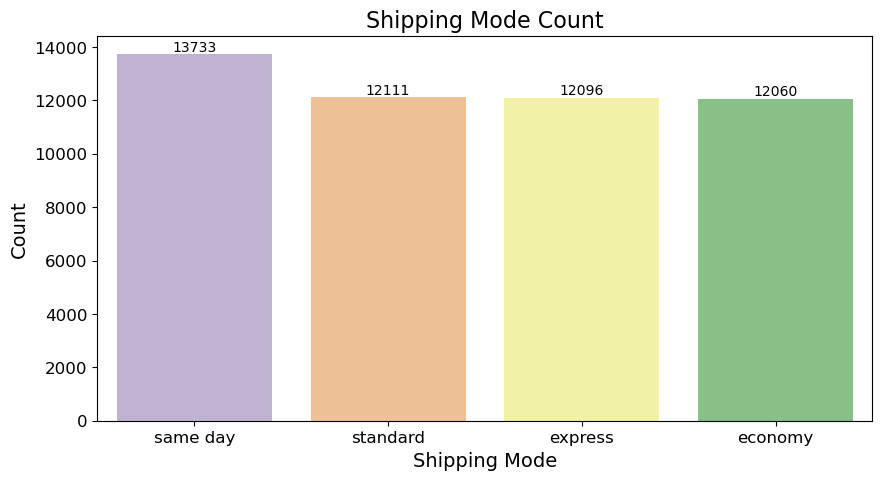

In [137]:
# shipping mode(count)

plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=sales,
    x='shipping_mode',
    order=sales['shipping_mode'].value_counts().index,
    palette='Accent',
    hue='shipping_mode',
    legend=False
)

# Data labels
for bars in ax.containers:
    ax.bar_label(bars)

# Titles
plt.title('Shipping Mode Count', fontsize=16)
plt.xlabel('Shipping Mode', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Axis sizes
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()


In [ ]:
#  the most used shipping mode is same_day 

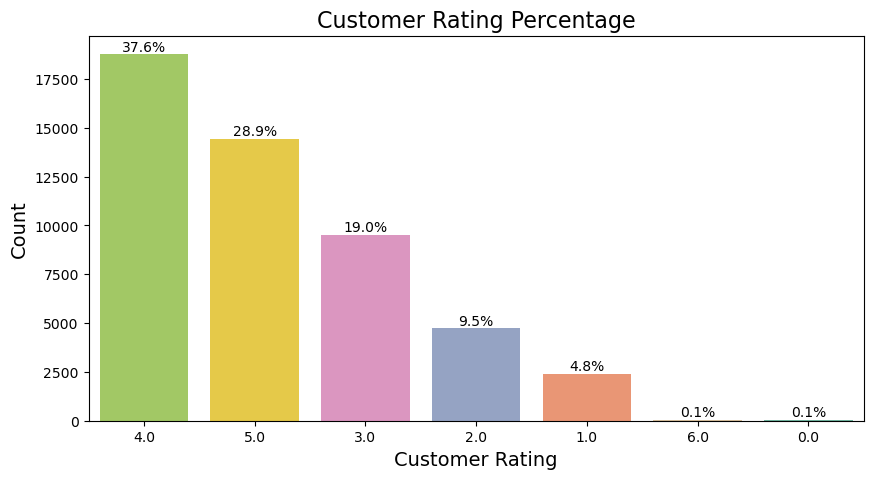

In [143]:
# customer_rating (count percentage)

plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=sales,
    x='customer_rating',
    order=sales['customer_rating'].value_counts().index,
    palette='Set2',
    hue='customer_rating',
    legend=False
)

# Percentage labels
total = len(sales)

for bars in ax.containers:
    labels = [f'{(v.get_height()/total)*100:.1f}%' for v in bars]
    ax.bar_label(bars, labels=labels)

# Titles
plt.title('Customer Rating Percentage', fontsize=16)
plt.xlabel('Customer Rating', fontsize=14)
plt.ylabel('Count', fontsize=14)

plt.show()

In [ ]:
insight: ~65+ customers within the 4 & 5 ratings , so it concludes most of the customer satified with product & service , only 0.1% customer gives the 0 ratings 

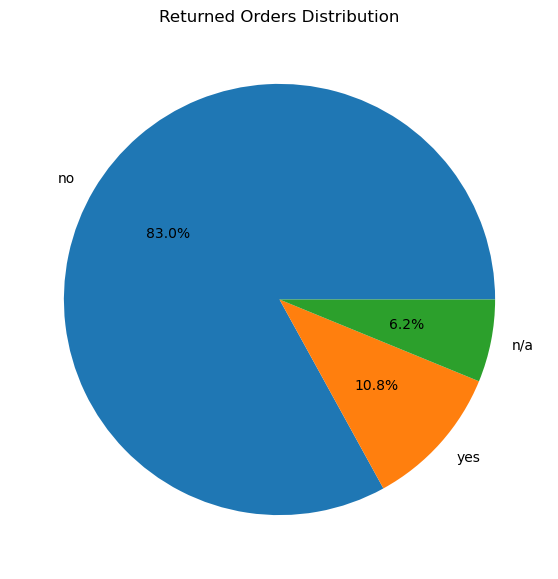

In [147]:
 # returned values (count)

# Count
returned_count = sales['returned'].value_counts()

# Figure size
plt.figure(figsize=(7,7))

# Pie chart
plt.pie(
    returned_count.values,
    labels=returned_count.index,
    autopct='%1.1f%%'
)

# Title
plt.title('Returned Orders Distribution')

plt.show()

# Insights: 

## Regional Analysis

The North region recorded the highest number of sales orders, whereas the Central region had the lowest sales count.

Interestingly, the Central region generated the highest overall sales revenue despite having fewer orders, while the North region contributed the lowest sales revenue.


## State-Level Analysis

Punjab recorded the highest sales count with more than 5,000 orders, while Tamil Nadu had the lowest sales count.

However, Tamil Nadu generated the highest sales revenue of approximately ₹37+ lakhs, indicating that customers from this state made comparatively higher-value purchases.


## Product Category Analysis

Customers showed the strongest preference for Beauty and Clothing categories.

The purchasing trend across categories remained fairly balanced, as no single category dominated the sales distribution significantly.


## Customer Segment Analysis

The Home Office customer segment generated both the highest number of purchases and the highest sales revenue.

Within this segment, Clothing emerged as the most preferred product category.


## Customer Value Analysis

Order ID "ORD-132612" was identified as the highest-value order/customer in the dataset.


## Sales Trend Analysis

Year-wise sales analysis revealed a consistent growth trend over the years, indicating positive business expansion and increasing customer demand.


## Payment & Shipping Analysis

UPI was the most preferred payment method among customers.

Same Day delivery emerged as the most frequently selected shipping mode, suggesting strong customer preference for faster deliveries.


## Customer Satisfaction Analysis

More than 65% of customers provided ratings of 4 or 5, indicating a high level of satisfaction with the products and services.

Only 0.1% of customers gave a rating of 0, showing that customer dissatisfaction was extremely low.


## Return Analysis

Approximately 83% of orders were not returned, which suggests that the majority of customers were satisfied with their purchases.